In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [4]:
X,y=make_blobs(n_samples=1000, centers=3,n_features=2)

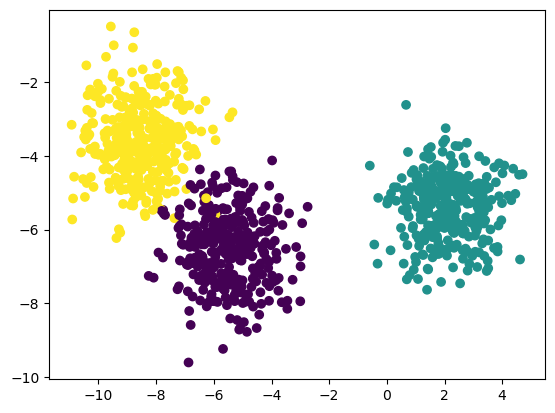

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.33, random_state=42
)

In [10]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [13]:
import os
os.environ["OMP_NUM_THREADS"] = "3"

from sklearn.cluster import KMeans

In [17]:
from threadpoolctl import threadpool_limits
from sklearn.cluster import KMeans

wcss = []

with threadpool_limits(limits=3, user_api="openmp"):
    for k in range(1, 11):
        kmeans = KMeans(
            n_clusters=k,
            init="k-means++",
            random_state=42,
            n_init=10
        )
        kmeans.fit(X_train_scaled)
        wcss.append(kmeans.inertia_)

In [18]:
wcss

[1340.0,
 631.8907801583512,
 265.76352850153586,
 198.36321474820187,
 155.23738819400558,
 113.93501043858654,
 97.68192307423082,
 87.48434062366167,
 77.77187225762624,
 70.6494689907405]

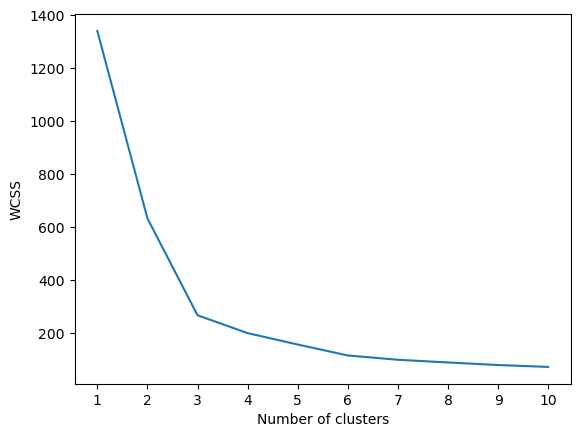

In [19]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [20]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [21]:
kmeans.fit_predict(X_train_scaled)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([1, 2, 0, 0, 1, 0, 0, 2, 0, 2, 0, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2,
       0, 2, 2, 2, 2, 2, 1, 2, 0, 1, 1, 0, 2, 1, 2, 2, 1, 2, 1, 1, 1, 0,
       0, 0, 0, 2, 2, 1, 0, 0, 1, 2, 1, 1, 0, 2, 0, 1, 2, 1, 2, 1, 2, 0,
       2, 2, 1, 1, 0, 0, 2, 0, 0, 2, 1, 2, 2, 0, 2, 2, 0, 0, 1, 2, 2, 2,
       0, 0, 0, 0, 2, 1, 0, 0, 0, 1, 2, 1, 2, 2, 2, 0, 0, 0, 2, 2, 2, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 2, 0, 2, 2, 1, 1, 0, 0, 2, 1, 2, 0, 1, 2,
       0, 1, 0, 0, 2, 2, 0, 2, 0, 0, 0, 2, 2, 2, 0, 1, 1, 2, 2, 2, 2, 2,
       1, 2, 2, 0, 1, 0, 2, 0, 2, 1, 2, 1, 2, 2, 0, 2, 0, 1, 2, 2, 2, 0,
       1, 0, 2, 0, 2, 1, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 2, 0, 2, 0, 1, 1,
       1, 2, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 0,
       1, 0, 1, 2, 2, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 2, 0, 2, 2, 0, 1, 0, 1, 1, 0, 2, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       2, 1, 1, 1, 1, 2, 2, 2, 0, 2, 0, 0, 2, 2, 2, 1, 2, 1, 0, 2, 1, 2,
       1, 0, 1, 0, 2, 1, 0, 1, 1, 0, 0, 1, 0, 0, 2,

In [22]:
y_pred=kmeans.predict(X_test_scaled)

In [23]:
y_pred

array([1, 0, 2, 1, 1, 1, 1, 1, 0, 0, 2, 1, 1, 2, 0, 2, 0, 2, 1, 1, 0, 0,
       2, 0, 1, 1, 0, 2, 1, 0, 0, 0, 2, 0, 0, 1, 1, 2, 2, 1, 2, 1, 1, 0,
       1, 1, 2, 0, 2, 2, 2, 2, 2, 1, 2, 1, 0, 1, 2, 0, 0, 1, 0, 2, 1, 1,
       2, 2, 1, 1, 2, 2, 2, 0, 1, 2, 2, 2, 0, 2, 1, 0, 0, 1, 2, 0, 0, 2,
       2, 1, 1, 1, 1, 0, 2, 0, 2, 2, 0, 2, 0, 0, 2, 2, 2, 0, 0, 0, 1, 2,
       1, 2, 1, 0, 0, 2, 2, 0, 0, 2, 1, 2, 1, 0, 0, 0, 2, 1, 0, 0, 1, 1,
       2, 1, 1, 0, 1, 2, 1, 1, 0, 2, 0, 0, 1, 0, 2, 1, 0, 2, 1, 2, 0, 2,
       2, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 0, 2, 1, 0, 1, 1, 1, 1, 2, 2,
       2, 1, 1, 0, 2, 0, 2, 0, 1, 1, 2, 2, 2, 2, 0, 1, 0, 2, 1, 2, 2, 2,
       2, 0, 1, 2, 1, 2, 2, 0, 2, 0, 1, 0, 2, 0, 0, 0, 1, 2, 2, 0, 1, 2,
       1, 0, 1, 1, 0, 2, 1, 2, 0, 1, 0, 2, 2, 0, 2, 1, 1, 2, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 0, 1,
       2, 0, 2, 0, 0, 0, 1, 0, 0, 2, 2, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 2,
       1, 0, 2, 1, 1, 2, 2, 0, 2, 0, 0, 2, 2, 2, 1,

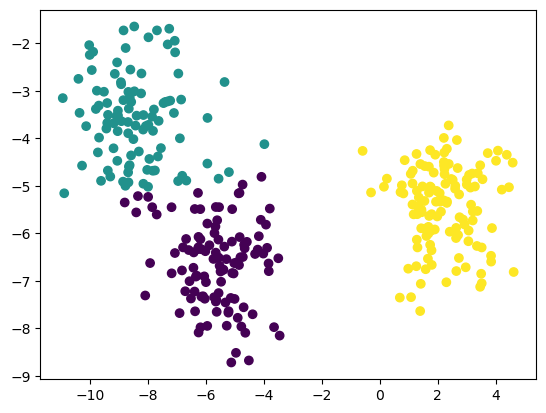

In [24]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [25]:
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [28]:
import sys
!{sys.executable} -m pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [31]:
!C:\ProgramData\anaconda3\python.exe -m pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [34]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--user",
    "--force-reinstall",
    "kneed"
])

0

In [35]:
from kneed import KneeLocator

ModuleNotFoundError: No module named 'kneed'

In [36]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

NameError: name 'KneeLocator' is not defined

In [37]:
kl.elbow

NameError: name 'kl' is not defined

In [38]:
from sklearn.metrics import silhouette_score

In [39]:
silhouette_coeff=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coeff.append(score)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [40]:
silhouette_coeff

[0.4722922714555449,
 0.595880160412867,
 0.5245377000339801,
 0.49448863811208177,
 0.47442500171278906,
 0.4328960293232329,
 0.392130713769396,
 0.38719329043020556,
 0.37445232964380354]